In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import janitor
import sklearn as skl
import random
import seaborn as sns

import clean  

In [2]:
# Set random seed for reproducibility
seed = 47

# Load the data and call it "df"
df = pd.read_csv('../data/TBI PUD 10-08-2013.csv')

# Test train split
train_df, test_df = skl.model_selection.train_test_split(df, test_size=0.2, random_state=seed)



In [3]:
# Clean training data with perturbations

# This is our default cleaned training data, which includes severe cases and extreme caution cases.
train_df_severe_true = clean.clean_data(train_df, include_severe_cases = True)

test_df_severe_true = clean.clean_data(test_df, include_severe_cases = True)

train_df_severe_false = clean.clean_data(train_df, include_severe_cases = False)

test_df_severe_false = clean.clean_data(test_df, include_severe_cases = False)

#train_df_suspected_loc_true = clean.clean_data(train_df, suspected_loc = True)

#train_df_suspected_loc_false = clean.clean_data(train_df, suspected_loc = False)

#train_df_extreme_caution_true = clean.clean_data(train_df, extreme_caution = True)

#train_df_extreme_caution_false = clean.clean_data(train_df, extreme_caution = False)


Make note that we will not check all combinations--too much

# Findings

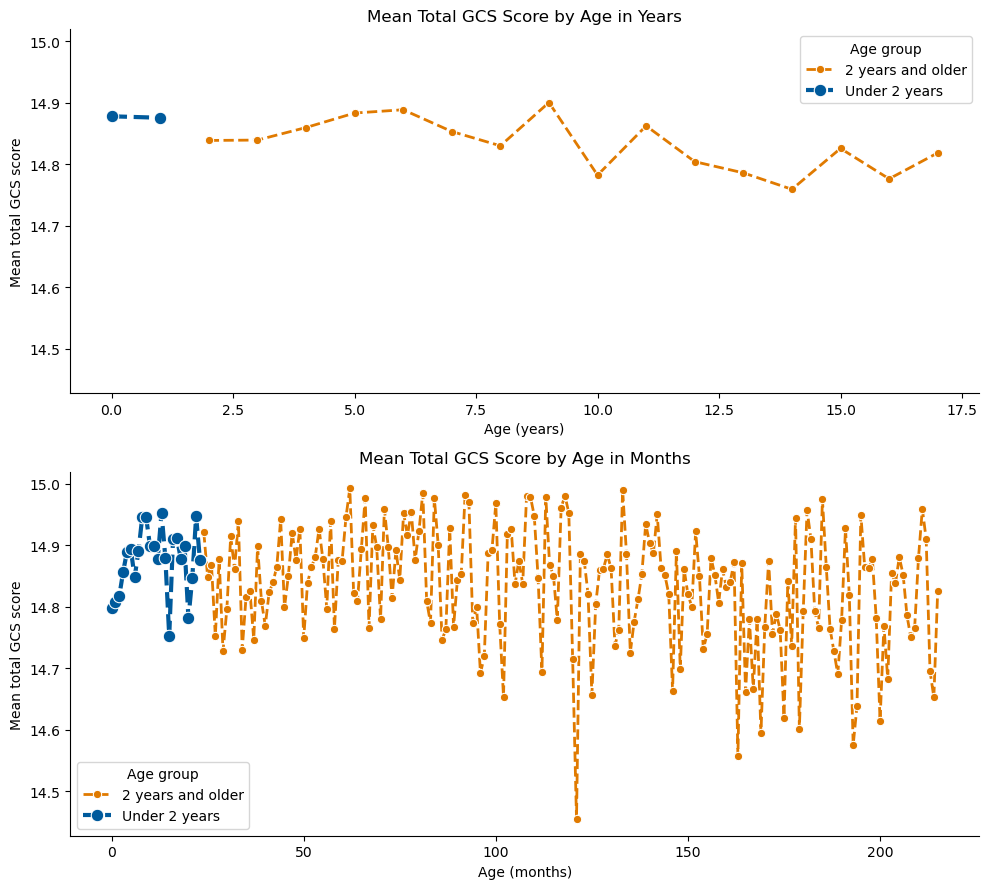

In [4]:
# Mean total GCS score by age in years and months for each age group.
gcs_plot_df = train_df_severe_true[['ageinyears', 'ageinmonth', 'gcstotal']].dropna().copy()
gcs_plot_df['age_group'] = np.where(
    gcs_plot_df['ageinyears'] < 2,
    'Under 2 years',
    '2 years and older'
)

average_gcs_years = (
    gcs_plot_df
    .groupby(['age_group', 'ageinyears'], as_index=False)['gcstotal']
    .mean()
)
average_gcs_months = (
    gcs_plot_df
    .groupby(['age_group', 'ageinmonth'], as_index=False)['gcstotal']
    .mean()
)

age_group_colors = {
    'Under 2 years': '#005A9C',
    '2 years and older': '#E07A00'
}
age_group_order = ['2 years and older', 'Under 2 years']

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharey=True)

for age_group in age_group_order:
    years_subset = average_gcs_years[average_gcs_years['age_group'] == age_group]
    months_subset = average_gcs_months[average_gcs_months['age_group'] == age_group]
    line_width = 3 if age_group == 'Under 2 years' else 2
    marker_size = 9 if age_group == 'Under 2 years' else 6

    sns.lineplot(
        data=years_subset,
        x='ageinyears',
        y='gcstotal',
        marker='o',
        linestyle='--',
        linewidth=line_width,
        markersize=marker_size,
        color=age_group_colors[age_group],
        label=age_group,
        errorbar=None,
        ax=axes[0]
    )
    sns.lineplot(
        data=months_subset,
        x='ageinmonth',
        y='gcstotal',
        marker='o',
        linestyle='--',
        linewidth=line_width,
        markersize=marker_size,
        color=age_group_colors[age_group],
        label=age_group,
        errorbar=None,
        ax=axes[1]
    )

axes[0].set_title('Mean Total GCS Score by Age in Years')
axes[0].set_xlabel('Age (years)')
axes[1].set_title('Mean Total GCS Score by Age in Months')
axes[1].set_xlabel('Age (months)')

for ax in axes:
    ax.set_ylabel('Mean total GCS score')
    ax.legend(title='Age group')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figs/mean_gcs_by_age.png', dpi=300)
plt.show()

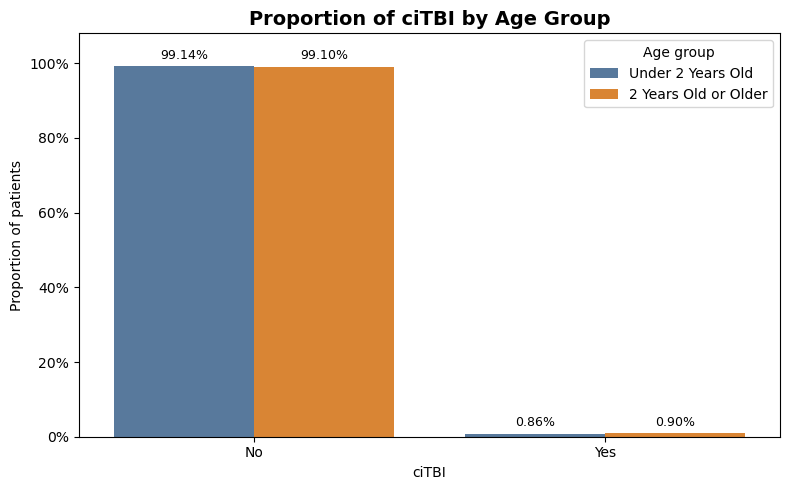

In [5]:
# Plot ciTBI proportions by age group after excluding severe GCS cases.
age_order = ['Under 2 Years Old', '2 Years Old or Older']
ci_tbi_order = ['No', 'Yes']

proportion_df = (
    train_df_severe_false.groupby(['agetwoplus', 'posintfinal'], observed=False)
    .size()
    .groupby(level='agetwoplus')
    .transform(lambda counts: counts / counts.sum())
    .rename('proportion')
    .reset_index()
)

colors = {'Under 2 Years Old': '#4C78A8', '2 Years Old or Older': '#F58518'}
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=proportion_df,
    x='posintfinal',
    y='proportion',
    hue='agetwoplus',
    order=ci_tbi_order,
    hue_order=age_order,
    palette=colors,
    ax=ax
)

for container in ax.containers:
    labels = [f'{bar.get_height():.2%}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

ax.set_title('Proportion of ciTBI by Age Group', fontsize=14, weight='bold')
ax.set_xlabel('ciTBI')
ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
ax.legend(title='Age group', loc='upper right')
plt.tight_layout()
plt.savefig('../figs/ciTBI_proportion_by_age_group_GCS_excluded.png', dpi=300, bbox_inches='tight')
plt.show()

## Stability Check

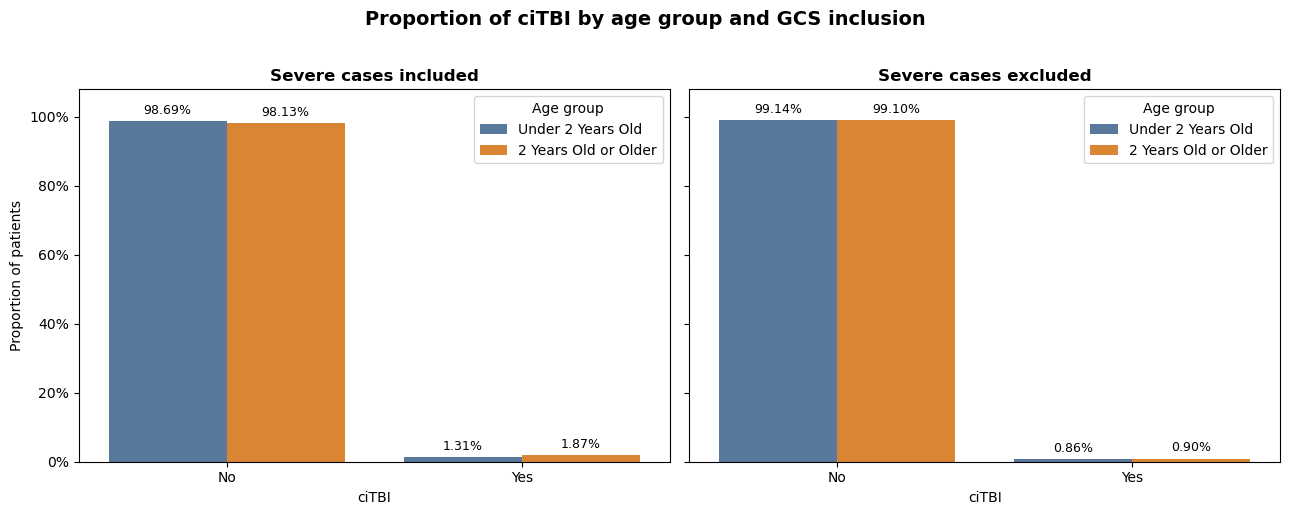

In [6]:
# Side-by-side plot of ciTBI proportions by age group with severe GCS cases included vs excluded.
plot_df = pd.concat(
    [
        train_df_severe_true.assign(gcs_filter='Severe cases included'),
        train_df_severe_false.assign(gcs_filter='Severe cases excluded')
    ],
    ignore_index=True
)

age_order = ['Under 2 Years Old', '2 Years Old or Older']
ci_tbi_order = ['No', 'Yes']
filter_order = ['Severe cases included', 'Severe cases excluded']

# Calculate proportions within each age group and GCS-filter condition.
proportion_df = (
    plot_df.groupby(['gcs_filter', 'agetwoplus', 'posintfinal'], observed=False)
    .size()
    .groupby(level=['gcs_filter', 'agetwoplus'])
    .transform(lambda counts: counts / counts.sum())
    .rename('proportion')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
colors = {'Under 2 Years Old': '#4C78A8', '2 Years Old or Older': '#F58518'}

for ax, filter_label in zip(axes, filter_order):
    subset = proportion_df[proportion_df['gcs_filter'] == filter_label]
    sns.barplot(
        data=subset,
        x='posintfinal',
        y='proportion',
        hue='agetwoplus',
        order=ci_tbi_order,
        hue_order=age_order,
        palette=colors,
        ax=ax
    )

    for container in ax.containers:
        labels = [f'{bar.get_height():.2%}' if bar.get_height() > 0 else '' for bar in container]
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

    ax.set_title(filter_label, fontsize=12, weight='bold')
    ax.set_xlabel('ciTBI')
    ax.set_ylabel('Proportion of patients' if ax is axes[0] else '')
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
    ax.legend(title='Age group', loc='upper right')

fig.suptitle('Proportion of ciTBI by age group and GCS inclusion', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figs/ciTBI_proportion_by_age_group_and_GCS_inclusion.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
proportion_df

,gcs_filter,agetwoplus,posintfinal,proportion
0,Severe cases excluded,2 Years Old or Older,No,0.991011
1,Severe cases excluded,2 Years Old or Older,Yes,0.008989
2,Severe cases excluded,Under 2 Years Old,No,0.991385
3,Severe cases excluded,Under 2 Years Old,Yes,0.008615
4,Severe cases included,2 Years Old or Older,No,0.981290
5,Severe cases included,2 Years Old or Older,Yes,0.018710
6,Severe cases included,Under 2 Years Old,No,0.986942
7,Severe cases included,Under 2 Years Old,Yes,0.013058


# Modeling

In [4]:
# Run CART on the training data with severe GCS cases excluded.
# Convert categorical predictors to dummy variables so the tree receives numeric inputs.
X_train = train_df_severe_false.drop(columns=['posintfinal']).copy()
y_train = train_df_severe_false['posintfinal'].copy()
X_test = test_df_severe_false.drop(columns=['posintfinal']).copy()
y_test = test_df_severe_false['posintfinal'].copy()

X_train = pd.get_dummies(X_train, dummy_na=True)
X_test = pd.get_dummies(X_test, dummy_na=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=False)

cart_clf = skl.tree.DecisionTreeClassifier(class_weight='balanced', random_state=seed)
param_grid = {'max_depth': list(range(1, 11))}
recall_scorer = skl.metrics.make_scorer(skl.metrics.recall_score, pos_label='Yes')

grid_search = skl.model_selection.GridSearchCV(
    cart_clf,
    param_grid,
    cv=5,
    scoring=recall_scorer
)

grid_search.fit(X_train, y_train)

# Results
print('Best tree depth:', grid_search.best_params_['max_depth'])
print('Best cross-validation score:', grid_search.best_score_)

best_tree = grid_search.best_estimator_
test_predictions = best_tree.predict(X_test)

print(
    'Test set recall:',
    skl.metrics.recall_score(y_test, test_predictions, pos_label='Yes')
)

Best tree depth: 2
Best cross-validation score: 0.7315300546448087
Test set recall: 0.8243243243243243


In [5]:
# Store the model and feature names for the comparison figure.
best_tree_excluded = best_tree
features_excluded = X_train.columns

In [6]:
# Run CART on the training data with severe GCS cases included.
# Convert categorical predictors to dummy variables so the tree receives numeric inputs.
X_train = train_df_severe_true.drop(columns=['posintfinal']).copy()
y_train = train_df_severe_true['posintfinal'].copy()
X_test = test_df_severe_true.drop(columns=['posintfinal']).copy()
y_test = test_df_severe_true['posintfinal'].copy()

X_train = pd.get_dummies(X_train, dummy_na=True)
X_test = pd.get_dummies(X_test, dummy_na=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=False)

cart_clf = skl.tree.DecisionTreeClassifier(class_weight='balanced', random_state=seed)
param_grid = {'max_depth': list(range(1, 11))}
recall_scorer = skl.metrics.make_scorer(skl.metrics.recall_score, pos_label='Yes')

grid_search = skl.model_selection.GridSearchCV(
    cart_clf,
    param_grid,
    cv=5,
    scoring=recall_scorer
)

grid_search.fit(X_train, y_train)

# Results
print('Best tree depth:', grid_search.best_params_['max_depth'])
print('Best cross-validation score:', grid_search.best_score_)

best_tree = grid_search.best_estimator_
test_predictions = best_tree.predict(X_test)

print(
    'Test set recall:',
    skl.metrics.recall_score(y_test, test_predictions, pos_label='Yes')
)

best_tree_included = best_tree
features_included = X_train.columns

Best tree depth: 3
Best cross-validation score: 0.8300000000000001
Test set recall: 0.8650306748466258


[Text(0.5, 0.875, 'amsoth_nan <= 0.5\ngini = 0.5\nsamples = 34705\nvalue = [17352.5, 17352.5]\nclass = Yes'),
 Text(0.25, 0.625, 'gcstotal <= 14.5\ngini = 0.25\nsamples = 5142\nvalue = [2373.026, 13824.158]\nclass = Yes'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'gcstotal <= 13.5\ngini = 0.12\nsamples = 1850\nvalue = [748.439, 10960.996]\nclass = Yes'),
 Text(0.0625, 0.125, 'gini = 0.051\nsamples = 751\nvalue = [230.485, 8618.408]\nclass = Yes'),
 Text(0.1875, 0.125, 'gini = 0.297\nsamples = 1099\nvalue = [517.955, 2342.587]\nclass = Yes'),
 Text(0.375, 0.375, 'hemaloc_parietal/temporal <= 0.5\ngini = 0.462\nsamples = 3292\nvalue = [1624.587, 2863.162]\nclass = Yes'),
 Text(0.3125, 0.125, 'gini = 0.493\nsamples = 2906\nvalue = [1446.508, 1822.013]\nclass = Yes'),
 Text(0.4375, 0.125, 'gini = 0.249\nsamples = 386\nvalue = [178.079, 1041.15]\nclass = Yes'),
 Text(0.75, 0.625, 'sfxpalp_No <= 0.5\ngini = 0.309\nsamples = 29563\nvalue = [14979.474, 3528.342]\nclass = No'),
 Text(0

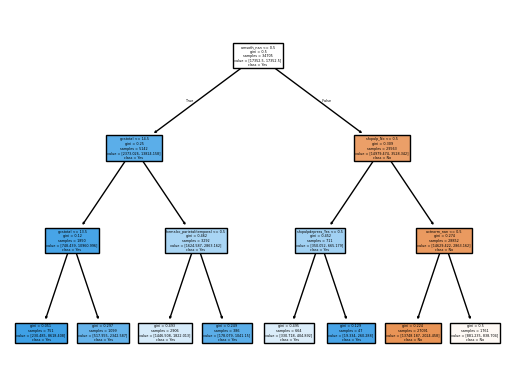

In [11]:
skl.tree.plot_tree(best_tree, feature_names=X_train.columns, class_names=['No', 'Yes'], filled=True)


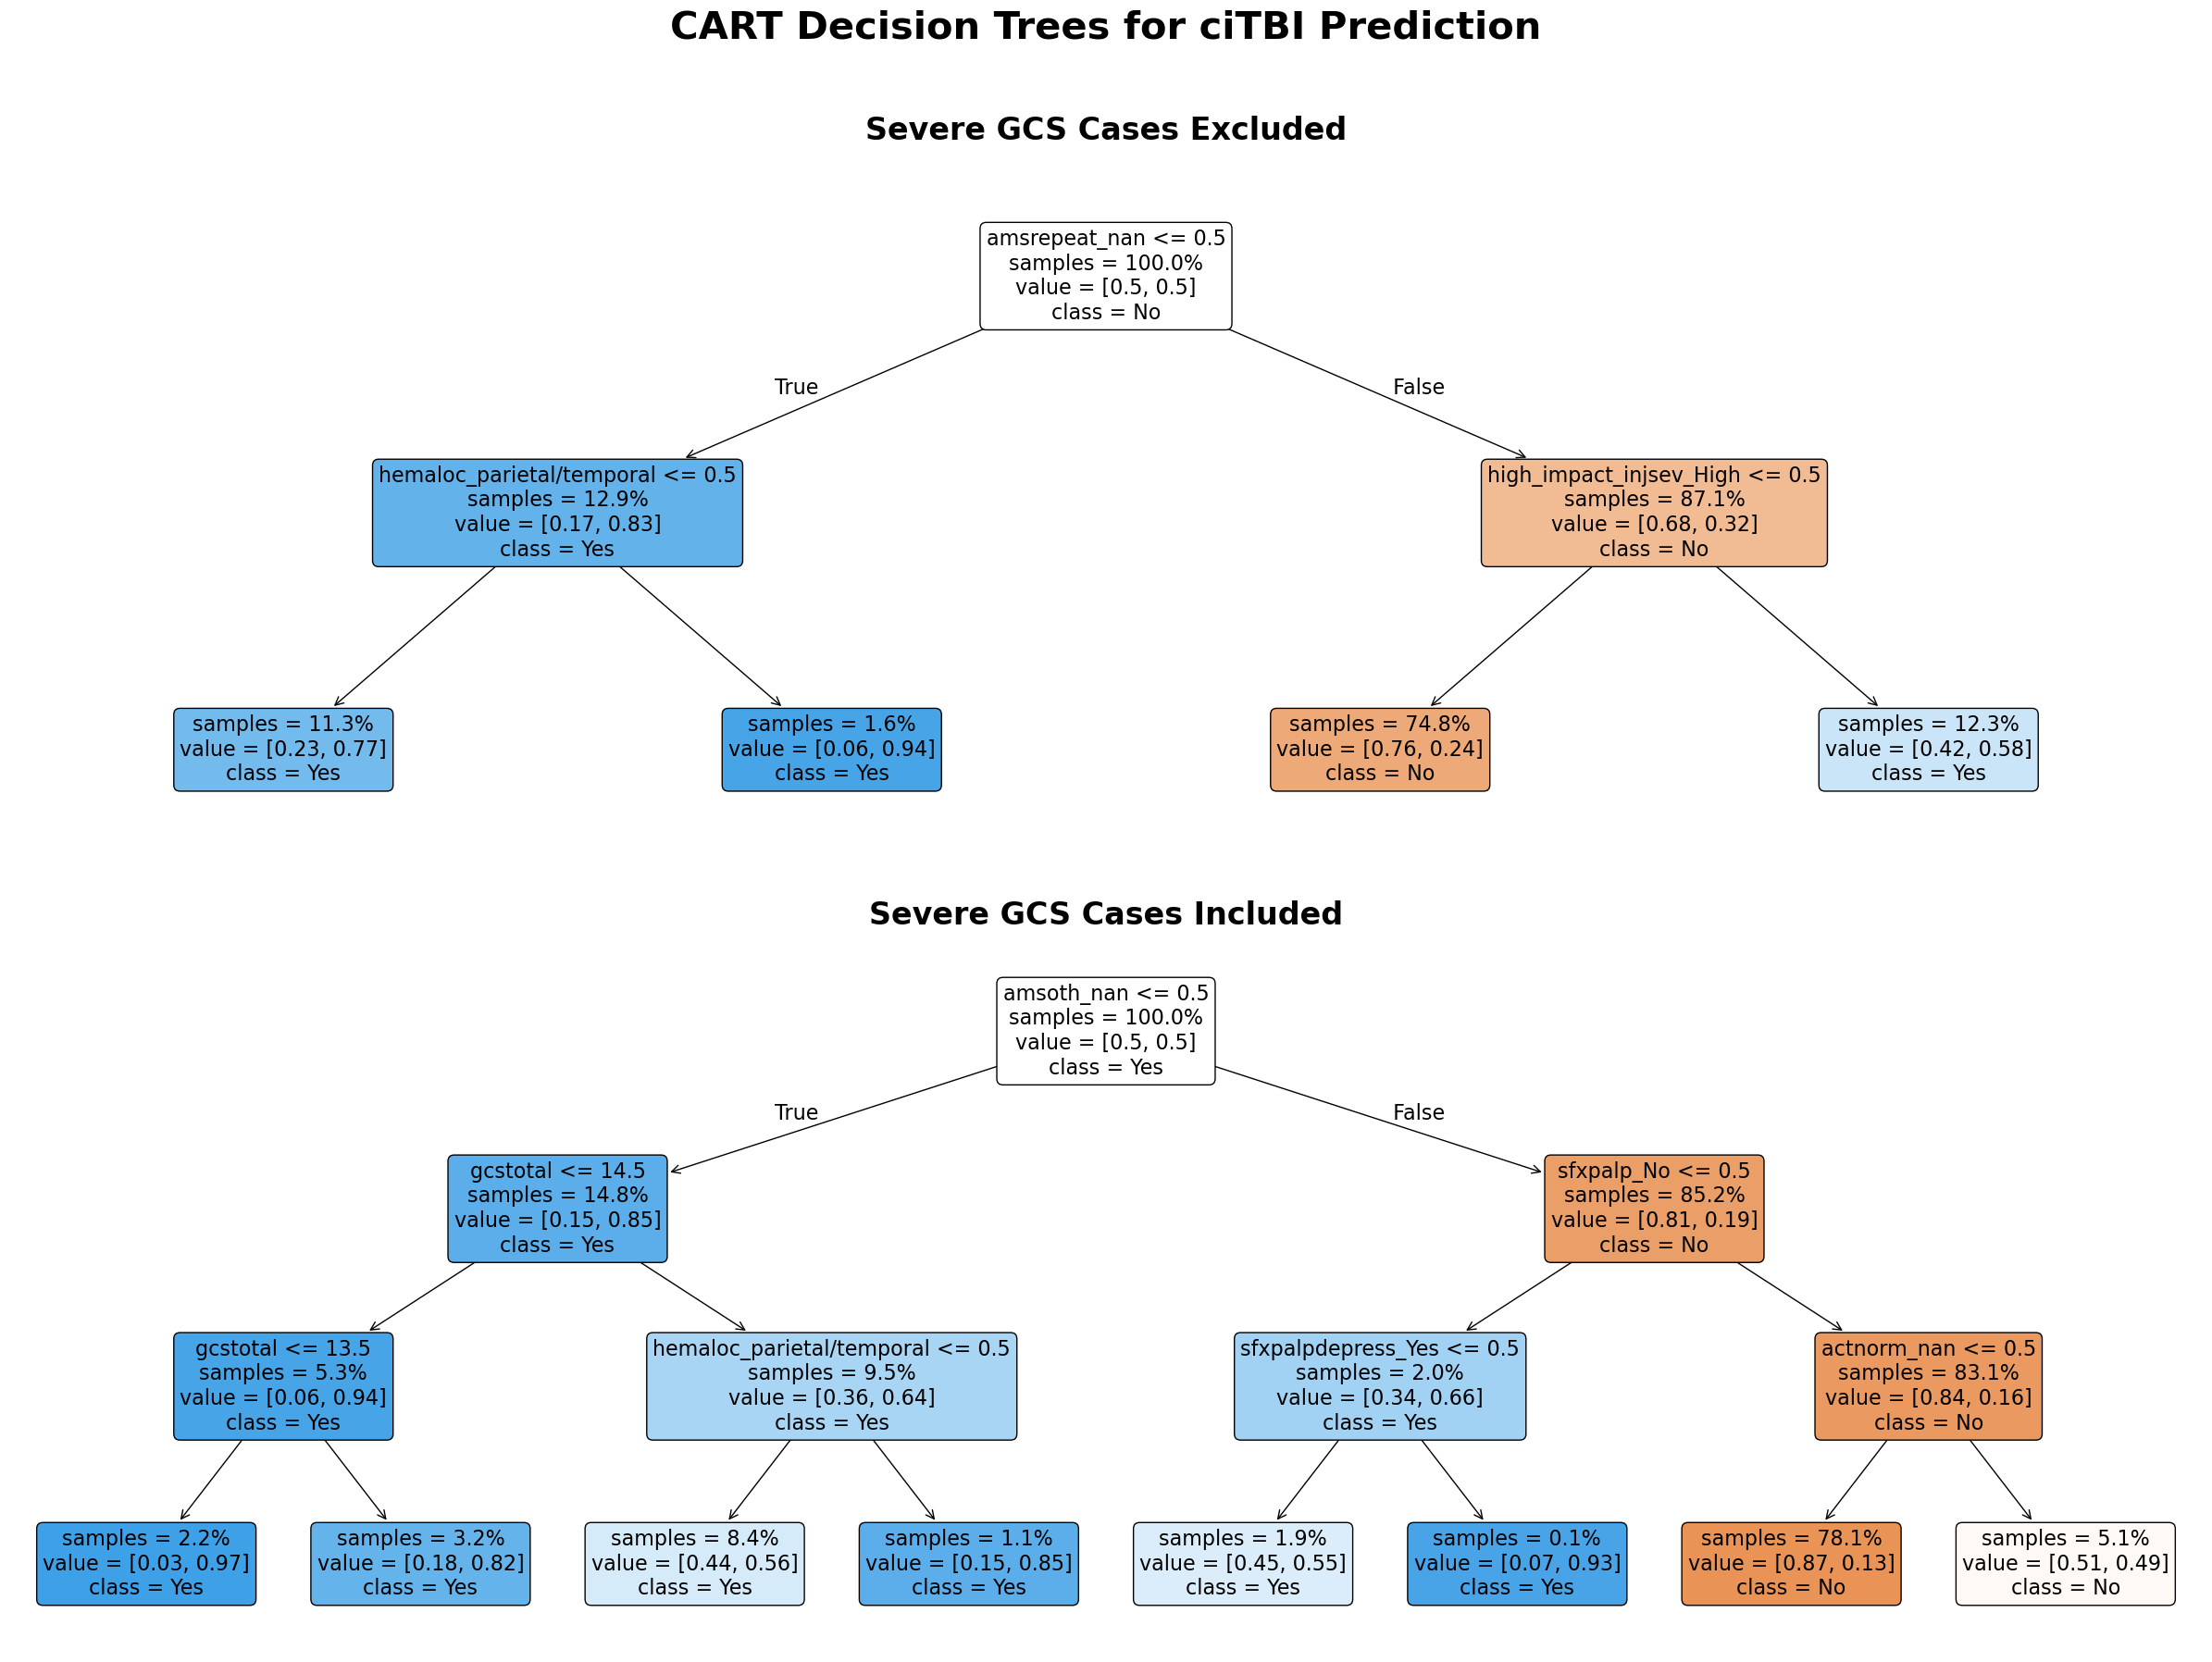

In [10]:
# Compare the CART trees with severe GCS cases excluded versus included.
fig, axes = plt.subplots(2, 1, figsize=(24, 18))

for ax, tree, features, title in [
    (axes[0], best_tree_excluded, features_excluded, 'Severe GCS Cases Excluded'),
    (axes[1], best_tree_included, features_included, 'Severe GCS Cases Included')
]:
    skl.tree.plot_tree(
        tree,
        feature_names=features,
        class_names=['No', 'Yes'],
        filled=True,
        rounded=True,
        proportion=True,
        impurity=False,
        precision=2,
        fontsize=16,
        ax=ax
    )
    ax.set_title(title, fontsize=24, weight='bold', pad=14)

fig.suptitle('CART Decision Trees for ciTBI Prediction', fontsize=30, weight='bold', y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.5)
fig.savefig('../figs/cart_tree_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Gradient boosted trees with severe GCS cases excluded. Cross validate to train hyperparameters. Class wieghts are balanced to account for class imbalance..

# 1. Prepare features (pd.get_dummies will leave NaNs in numeric columns, which is fine for HistGradientBoostingClassifier)
X_train = train_df_severe_false.drop(columns=['posintfinal']).copy()
y_train = train_df_severe_false['posintfinal'].copy()
X_test = test_df_severe_false.drop(columns=['posintfinal']).copy()
y_test = test_df_severe_false['posintfinal'].copy()

X_train = pd.get_dummies(X_train, dummy_na=True)
X_test = pd.get_dummies(X_test, dummy_na=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=False)

# 2. Define the model with class_weight='balanced'
hgb_clf = skl.ensemble.HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=seed
)

# Note: max_depth works differently in HGB; max_iter is used instead of n_estimators
param_grid = {
    'max_iter': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

recall_scorer = skl.metrics.make_scorer(skl.metrics.recall_score, pos_label='Yes')

grid_search = skl.model_selection.GridSearchCV(
    estimator=hgb_clf,
    param_grid=param_grid,
    cv=5,
    scoring=recall_scorer,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation score:', grid_search.best_score_)

# 3. Predict on test set using the best estimator found by GridSearchCV
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)

print('Test set recall:', skl.metrics.recall_score(y_test, predictions, pos_label='Yes'))





Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 50}
Best cross-validation score: 0.7481967213114755
Test set recall: 0.8378378378378378


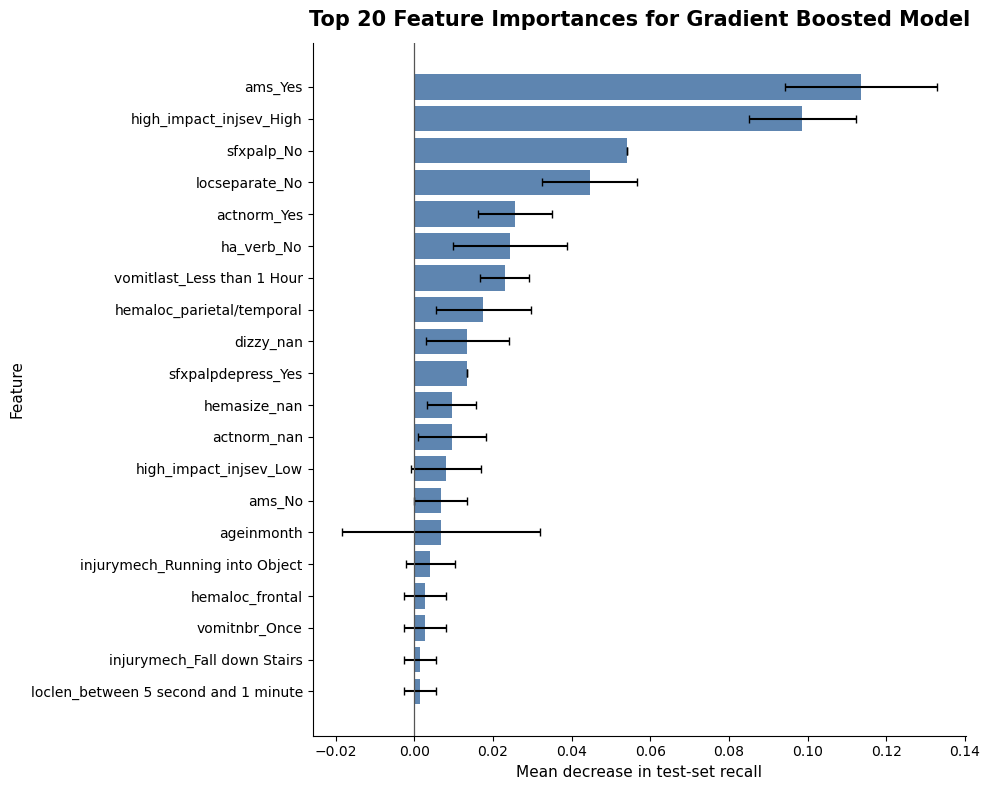

In [16]:
# Plot permutation feature importance for the best gradient boosted model.
# HistGradientBoostingClassifier does not provide feature_importances_, so use the test set.
permutation_result = skl.inspection.permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring=recall_scorer,
    n_repeats=10,
    random_state=seed,
    n_jobs=-1
)

feature_importance_df = (
    pd.DataFrame({
        'feature': X_test.columns,
        'importance': permutation_result.importances_mean,
        'std': permutation_result.importances_std
    })
    .sort_values('importance', ascending=False)
)

top_features = feature_importance_df.head(20).sort_values('importance')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_features['feature'],
    top_features['importance'],
    xerr=top_features['std'],
    color='#4C78A8',
    alpha=0.9,
    capsize=3
)
ax.axvline(0, color='#555555', linewidth=0.9)
ax.set_title('Top 20 Feature Importances for Gradient Boosted Model', fontsize=15, weight='bold', pad=12)
ax.set_xlabel('Mean decrease in test-set recall', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig('../figs/gradient_boosting_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Gradient boosted trees with severe GCS cases excluded. Cross validate to train hyperparameters. Class wieghts are balanced to account for class imbalance..

# 1. Prepare features (pd.get_dummies will leave NaNs in numeric columns, which is fine for HistGradientBoostingClassifier)
X_train = train_df_severe_true.drop(columns=['posintfinal']).copy()
y_train = train_df_severe_true['posintfinal'].copy()
X_test = test_df_severe_true.drop(columns=['posintfinal']).copy()
y_test = test_df_severe_true['posintfinal'].copy()

X_train = pd.get_dummies(X_train, dummy_na=True)
X_test = pd.get_dummies(X_test, dummy_na=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=False)

# 2. Define the model with class_weight='balanced'
hgb_clf = skl.ensemble.HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=seed
)

# Note: max_depth works differently in HGB; max_iter is used instead of n_estimators
param_grid = {
    'max_iter': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

recall_scorer = skl.metrics.make_scorer(skl.metrics.recall_score, pos_label='Yes')

grid_search = skl.model_selection.GridSearchCV(
    estimator=hgb_clf,
    param_grid=param_grid,
    cv=5,
    scoring=recall_scorer,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation score:', grid_search.best_score_)

# 3. Predict on test set using the best estimator found by GridSearchCV
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)

print('Test set recall:', skl.metrics.recall_score(y_test, predictions, pos_label='Yes'))

Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'max_iter': 50}
Best cross-validation score: 0.8200000000000001
Test set recall: 0.8711656441717791
